# Exploratory Data Analysis (EDA) on the Titanic Dataset

## Objective

The objective of this project is to explore the Titanic dataset to understand its structure, identify missing values and inconsistencies, analyze feature distributions, discover relationships between variables, and derive meaningful insights using statistical summaries and visualizations.

---

In [3]:
import pandas as pd

df = pd.read_csv("titanic.csv")

In [4]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.shape

(891, 12)

In [6]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

### Observation

- Most columns contain complete data with no missing values.
- The `Age` column has 177 missing values and will require imputation before further analysis.
- The `Cabin` column has 687 missing values (approximately 77% of the dataset), making it a strong candidate for removal.
- The `Embarked` column has only 2 missing values, which can be handled easily during data cleaning.

## 2. Statistical Summary

After understanding the structure and quality of the dataset, the next step is to examine the statistical properties of the numerical features. This helps identify the central tendency, spread, and potential outliers.

In [10]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

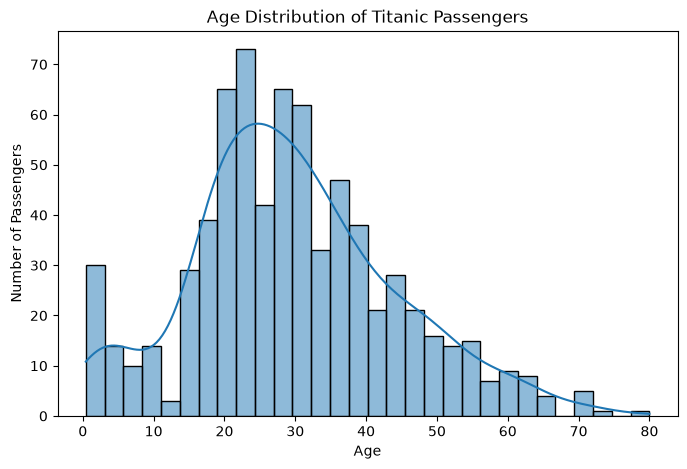

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(df["Age"], bins=30, kde=True)

plt.title("Age Distribution of Titanic Passengers")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

## 3. Univariate Analysis - Categorical Variables

Categorical variables help us understand the distribution of different groups within the dataset. In this section, we examine variables such as passenger gender, passenger class, and embarkation port.

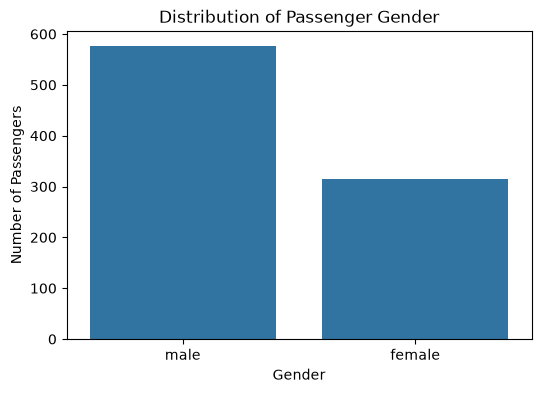

In [29]:
plt.figure(figsize=(6,4))

sns.countplot(x='Sex', data=df)

plt.title("Distribution of Passenger Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")
plt.savefig("images/gender_distribution.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

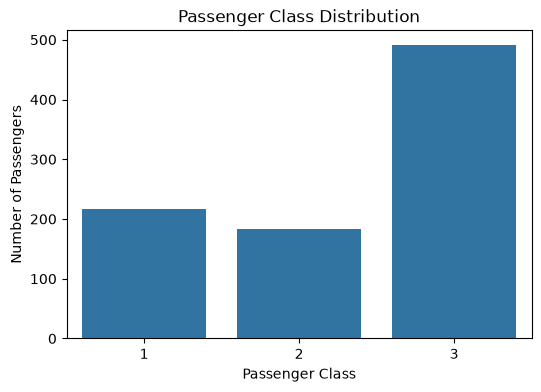

In [30]:
plt.figure(figsize=(6,4))

sns.countplot(x='Pclass', data=df)

plt.title("Passenger Class Distribution")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.savefig("images/passenger_class.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

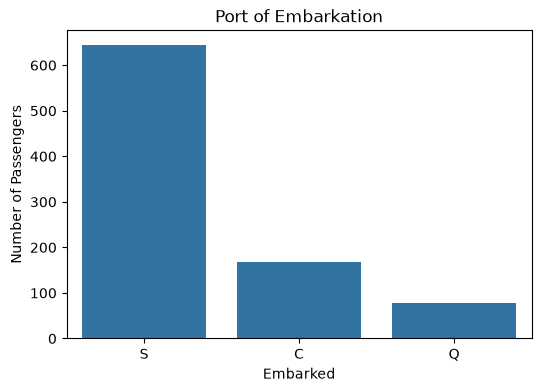

In [31]:
plt.figure(figsize=(6,4))

sns.countplot(x='Embarked', data=df)

plt.title("Port of Embarkation")
plt.xlabel("Embarked")
plt.ylabel("Number of Passengers")
plt.savefig("images/embarked_distribution.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

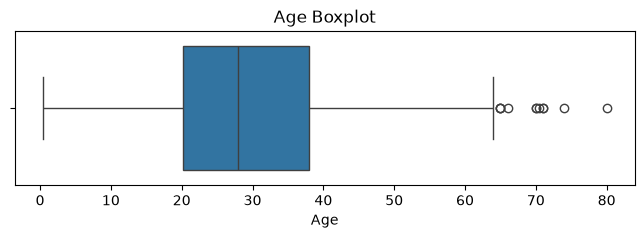

In [16]:
plt.figure(figsize=(8,2))

sns.boxplot(x=df["Age"])

plt.title("Age Boxplot")

plt.show()

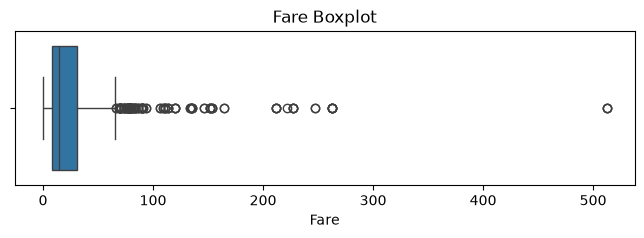

In [17]:
plt.figure(figsize=(8,2))

sns.boxplot(x=df["Fare"])

plt.title("Fare Boxplot")

plt.show()

## 4. Bivariate Analysis

Bivariate analysis examines the relationship between two variables. In this section, we investigate how different passenger characteristics influenced survival.

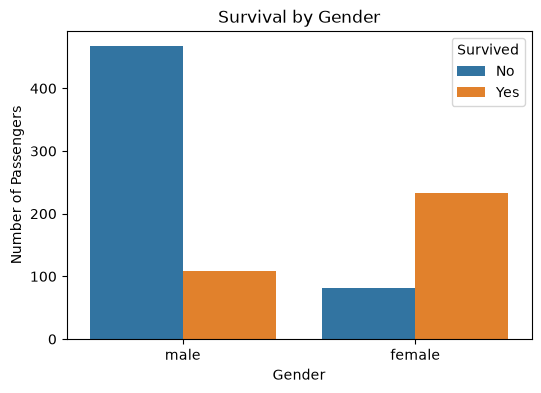

In [32]:
plt.figure(figsize=(6,4))

sns.countplot(x='Sex', hue='Survived', data=df)

plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")

plt.legend(title="Survived", labels=["No", "Yes"])
plt.savefig("images/survival_by_gender.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

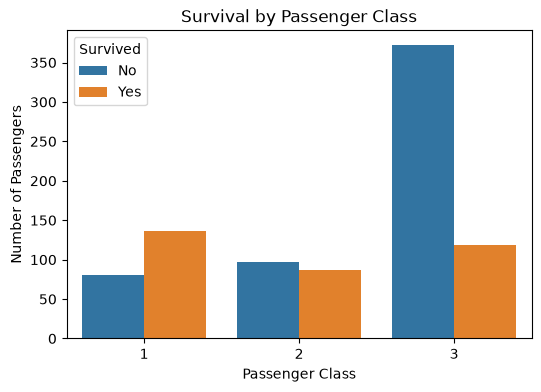

In [33]:
plt.figure(figsize=(6,4))

sns.countplot(x='Pclass', hue='Survived', data=df)

plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")

plt.legend(title="Survived", labels=["No", "Yes"])
plt.savefig("images/survival_by_class.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

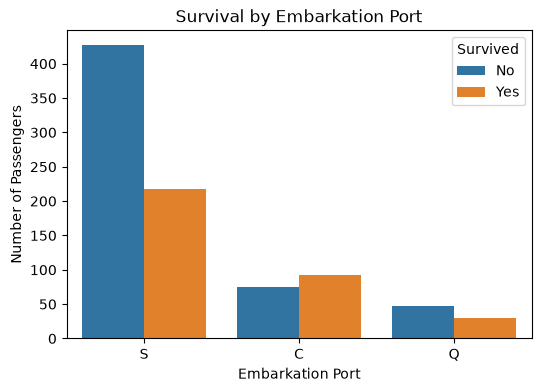

In [34]:
plt.figure(figsize=(6,4))

sns.countplot(x='Embarked', hue='Survived', data=df)

plt.title("Survival by Embarkation Port")
plt.xlabel("Embarkation Port")
plt.ylabel("Number of Passengers")

plt.legend(title="Survived", labels=["No", "Yes"])
plt.savefig("images/survival_by_embarked.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

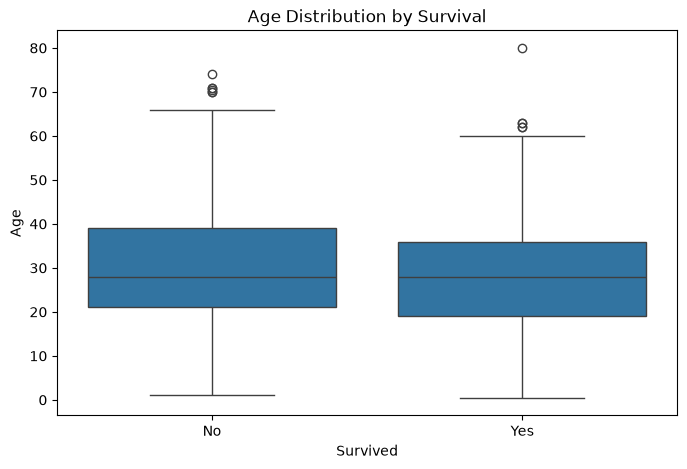

In [35]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Survived', y='Age', data=df)

plt.title("Age Distribution by Survival")
plt.xlabel("Survived")
plt.ylabel("Age")

plt.xticks([0,1],["No","Yes"])
plt.savefig("images/age_vs_survival.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

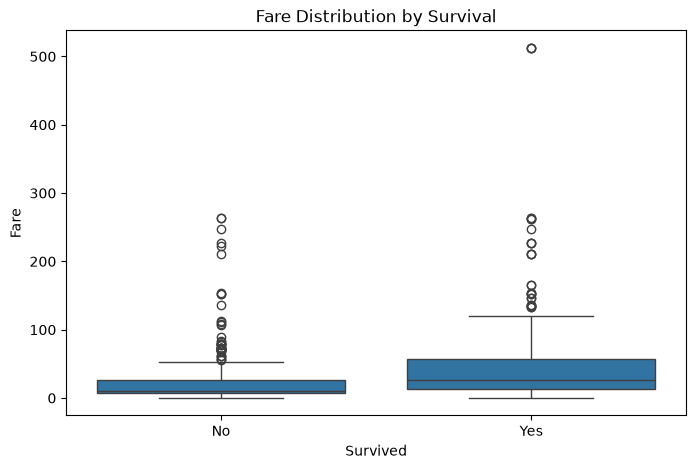

In [36]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Survived', y='Fare', data=df)

plt.title("Fare Distribution by Survival")
plt.xlabel("Survived")
plt.ylabel("Fare")

plt.xticks([0,1],["No","Yes"])
plt.savefig("images/fare_vs_survival.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

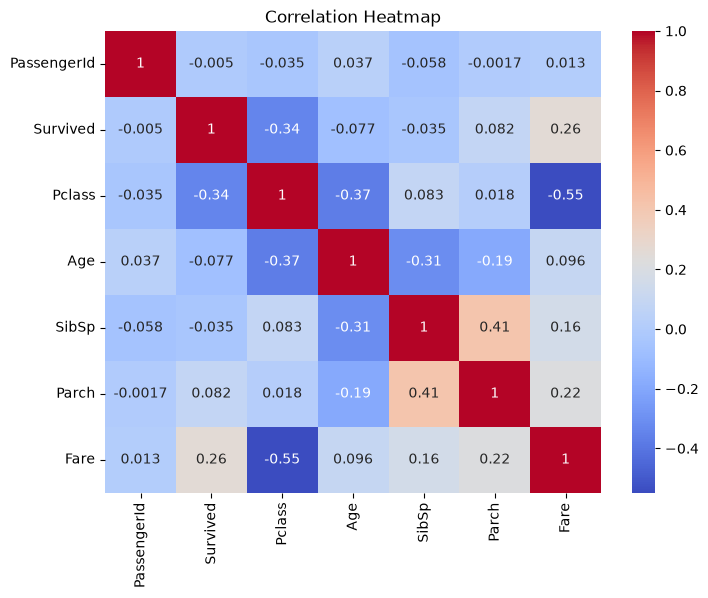

In [37]:
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.savefig("images/correlation_heatmap.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

## 5. Correlation Analysis

Correlation analysis measures the strength and direction of the relationship between numerical variables. A correlation heatmap provides a quick overview of how features are associated with one another.

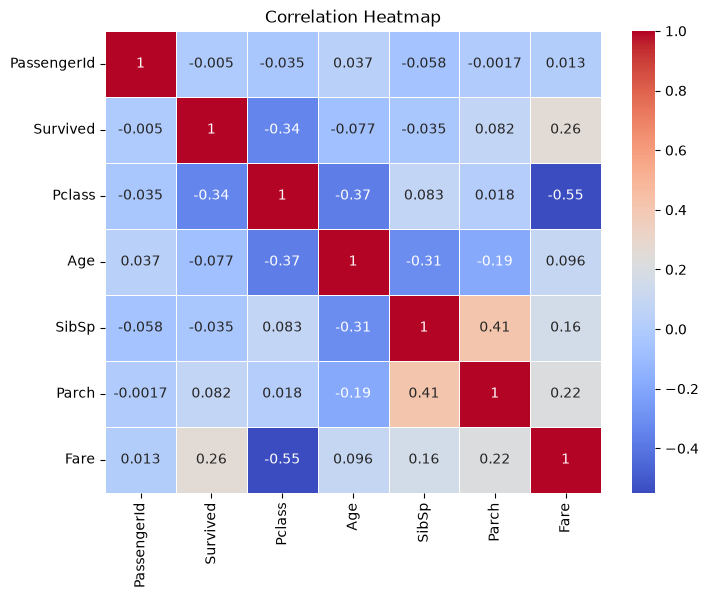

In [24]:
plt.figure(figsize=(8,6))

correlation = df.corr(numeric_only=True)

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

## 6. Key Insights

- The dataset contains 891 passenger records and 12 features.
- The `Cabin` column has a high percentage of missing values (approximately 77%).
- Most passengers were between 20 and 40 years of age.
- Male passengers outnumbered female passengers.
- Third-class passengers formed the largest group.
- Female passengers had a significantly higher survival rate than male passengers.
- First-class passengers survived more frequently than third-class passengers.
- Higher ticket fares were generally associated with higher survival rates.
- Most passengers embarked from Southampton (S).
- The dataset showed no duplicate records.

## 7. Conclusion

This exploratory data analysis provided valuable insights into the Titanic dataset. The dataset was generally clean, with missing values primarily in the `Age`, `Cabin`, and `Embarked` columns. Statistical summaries and visualizations revealed that most passengers were young adults, males constituted the majority of passengers, and third-class travelers formed the largest group. Bivariate analysis showed that gender, passenger class, and ticket fare had a noticeable influence on survival, while age showed a comparatively weaker relationship. Overall, the dataset demonstrates clear patterns that can be used for further predictive modeling after appropriate data preprocessing.

## Age Distribution

A histogram is used to understand how passenger ages are distributed and identify the most common age groups.

<Axes: xlabel='Age', ylabel='Count'>

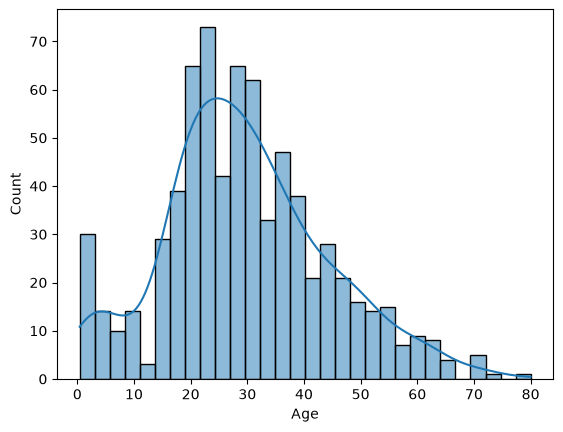

In [25]:
sns.histplot(df["Age"], bins=30, kde=True)

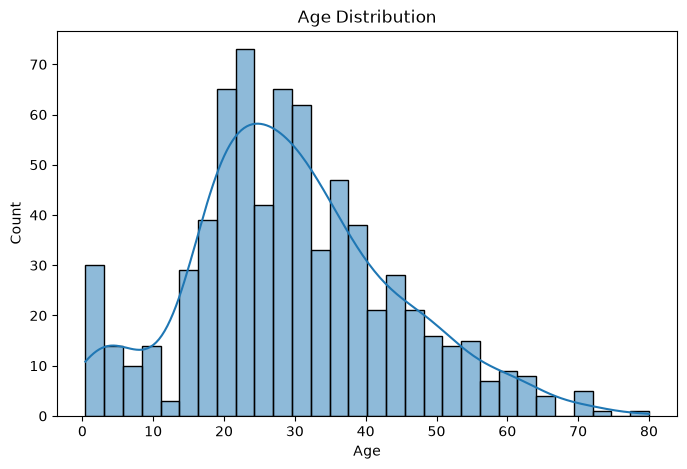

In [27]:
plt.figure(figsize=(8,5))

sns.histplot(df["Age"], bins=30, kde=True)

plt.title("Age Distribution")

plt.savefig("age_distribution.png", dpi=300, bbox_inches="tight")
